# S09 : Metrics for Rule Application: Coverage, Recall, Branching, and Cost



## Aim of this talktorial

## Learning outcomes


## Roadmap


In [1]:
from __future__ import annotations

import json
import gzip
from pathlib import Path
from typing import Any, Dict, Hashable, Iterable, List, Optional, Sequence, Tuple, Union

import numpy as np
import pandas as pd
import networkx as nx
import networkx.algorithms.isomorphism as iso

from rdkit import Chem
from rdkit.Chem import AllChem

import matplotlib.pyplot as plt


def load_json_auto(path: Union[str, Path]) -> Any:
    """
    Load JSON from .json or .json.gz.

    Auto-detects gzip by magic bytes, not filename.
    Works even if a file is misnamed *.json.gz but is plain JSON.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path.resolve()}")

    with open(path, "rb") as fb:
        magic = fb.read(2)

    is_gzip = magic == b"\x1f\x8b"
    if is_gzip:
        with gzip.open(path, "rt", encoding="utf-8") as f:
            return json.load(f)
    with open(path, "rt", encoding="utf-8") as f:
        return json.load(f)


print("RDKit:", getattr(Chem, "__version__", "unknown"))
print("NetworkX:", nx.__version__)

RDKit: unknown
NetworkX: 3.6.1


In [2]:
def to_records(obj: Any) -> List[Dict[str, Any]]:
    """
    Normalize a JSON object into a list of reaction records (dicts).

    Supports:
    - list[dict]
    - {"data": list[dict]} and common variants
    - dict[str, dict] (id -> record)
    """
    if isinstance(obj, list):
        return [r for r in obj if isinstance(r, dict)]
    if isinstance(obj, dict):
        for k in ("data", "reactions", "records", "items", "rxns"):
            v = obj.get(k)
            if isinstance(v, list) and v and isinstance(v[0], dict):
                return v
        # id -> record
        if obj and all(isinstance(v, dict) for v in obj.values()):
            return list(obj.values())
    raise TypeError(f"Unsupported data type: {type(obj)}")


def looks_like_mapped_rxn_smiles(s: str) -> bool:
    if not isinstance(s, str):
        return False
    if ">" not in s:
        return False
    # atom-map numbers typically appear as ":<int>]"
    return (":" in s) and ("]" in s) and any(tok in s for tok in (">>", ">"))


def guess_mapped_field(records: List[Dict[str, Any]]) -> str:
    """
    Heuristic: choose the first key whose value looks like an atom-mapped reaction SMILES.
    """
    if not records:
        raise ValueError("Empty records")
    keys = set().union(*(r.keys() for r in records[:50]))
    candidates: List[Tuple[int, str]] = []
    for k in keys:
        score = 0
        for r in records[:50]:
            v = r.get(k)
            if isinstance(v, str) and looks_like_mapped_rxn_smiles(v):
                score += 1
        if score:
            candidates.append((score, k))
    if not candidates:
        raise KeyError("Could not find a mapped reaction SMILES field automatically.")
    candidates.sort(reverse=True)
    return candidates[0][1]


def split_rxn_smiles(rxn: str) -> Tuple[List[str], List[str], List[str]]:
    """
    Split a reaction SMILES into (reactants, agents, products) lists.

    Accepts:
    - reactants>>products
    - reactants>agents>products
    """
    if ">>" in rxn:
        left, right = rxn.split(">>")
        return [s for s in left.split(".") if s], [], [s for s in right.split(".") if s]
    parts = rxn.split(">")
    if len(parts) == 3:
        left, mid, right = parts
        return (
            [s for s in left.split(".") if s],
            [s for s in mid.split(".") if s],
            [s for s in right.split(".") if s],
        )
    raise ValueError(f"Unrecognized reaction SMILES format: {rxn[:80]}...")

In [3]:
# --- Canonicalization (from S05, minimal subset) ---


def clear_atom_maps(m: Chem.Mol) -> Chem.Mol:
    mm = Chem.Mol(m)
    for a in mm.GetAtoms():
        a.SetAtomMapNum(0)
    return mm


def mol_key_unmapped(m: Chem.Mol) -> str:
    return Chem.MolToSmiles(clear_atom_maps(m), canonical=True)


def canonical_ranks_unmapped(m: Chem.Mol) -> List[int]:
    mm = clear_atom_maps(m)
    return list(Chem.CanonicalRankAtoms(mm, includeChirality=True))


def mapped_atoms_in_mol(m: Chem.Mol) -> List[Tuple[int, int]]:
    out = []
    for a in m.GetAtoms():
        mid = int(a.GetAtomMapNum() or 0)
        if mid > 0:
            out.append((a.GetIdx(), mid))
    return out


def canonical_map_renaming(mapped_rxn: str) -> Dict[int, int]:
    r_smis, _agents, p_smis = split_rxn_smiles(mapped_rxn)
    r_mols = [Chem.MolFromSmiles(s) for s in r_smis]
    p_mols = [Chem.MolFromSmiles(s) for s in p_smis]

    def collect(mols: List[Chem.Mol], side: int):
        items = []
        for m in sorted(mols, key=mol_key_unmapped):
            key_m = mol_key_unmapped(m)
            ranks = canonical_ranks_unmapped(m)
            for aidx, mid in mapped_atoms_in_mol(m):
                a = m.GetAtomWithIdx(aidx)
                k = (
                    side,
                    key_m,
                    int(ranks[aidx]),
                    a.GetSymbol(),
                    int(a.GetFormalCharge()),
                    bool(a.GetIsAromatic()),
                )
                items.append((k, mid))
        return items

    seen = {}
    for k, mid in collect(r_mols, 0):
        seen.setdefault(mid, k)
    for k, mid in collect(p_mols, 1):
        seen.setdefault(mid, k)

    ordered = sorted([(k, mid) for mid, k in seen.items()])
    return {mid: i + 1 for i, (k, mid) in enumerate(ordered)}


def apply_map_renaming_to_rxn(mapped_rxn: str, ren: Dict[int, int]) -> str:
    r_smis, agents, p_smis = split_rxn_smiles(mapped_rxn)
    r_mols = [Chem.MolFromSmiles(s) for s in r_smis]
    p_mols = [Chem.MolFromSmiles(s) for s in p_smis]
    a_mols = [Chem.MolFromSmiles(s) for s in agents] if agents else []

    for m in r_mols + p_mols + a_mols:
        for a in m.GetAtoms():
            mid = int(a.GetAtomMapNum() or 0)
            if mid > 0 and mid in ren:
                a.SetAtomMapNum(int(ren[mid]))

    def ms(m):
        return Chem.MolToSmiles(m, canonical=True)

    r_out = ".".join(ms(m) for m in sorted(r_mols, key=mol_key_unmapped))
    p_out = ".".join(ms(m) for m in sorted(p_mols, key=mol_key_unmapped))
    if agents:
        a_out = ".".join(ms(m) for m in sorted(a_mols, key=mol_key_unmapped))
        return f"{r_out}>{a_out}>{p_out}"
    return f"{r_out}>>{p_out}"


def canonicalize_mapped_rxn(mapped_rxn: str) -> str:
    return apply_map_renaming_to_rxn(mapped_rxn, canonical_map_renaming(mapped_rxn))


def unmap_smiles(sm: str) -> str:
    m = Chem.MolFromSmiles(sm)
    if m is None:
        raise ValueError(f"Bad SMILES: {sm}")
    return Chem.MolToSmiles(clear_atom_maps(m), canonical=True)


def rxn_sides_unmapped(mapped_rxn: str) -> Tuple[List[str], List[str]]:
    r_smis, _agents, p_smis = split_rxn_smiles(mapped_rxn)
    r = [unmap_smiles(s) for s in r_smis]
    p = [unmap_smiles(s) for s in p_smis]
    return r, p


def mixture_from_smiles_list(smis: List[str]) -> str:
    return ".".join(sorted(smis))

In [4]:
from dataclasses import dataclass
from collections import deque


def bond_order_rdkit(b: Chem.Bond) -> float:
    bt = b.GetBondType()
    if bt == Chem.rdchem.BondType.SINGLE:
        return 1.0
    if bt == Chem.rdchem.BondType.DOUBLE:
        return 2.0
    if bt == Chem.rdchem.BondType.TRIPLE:
        return 3.0
    if bt == Chem.rdchem.BondType.AROMATIC:
        return 1.5
    return float(b.GetBondTypeAsDouble())


def atoms_by_map_id(mols: List[Chem.Mol]) -> Dict[int, Chem.Atom]:
    out = {}
    for m in mols:
        for a in m.GetAtoms():
            mid = int(a.GetAtomMapNum() or 0)
            if mid > 0:
                out[mid] = a
    return out


def bonds_by_map_pair(mols: List[Chem.Mol]) -> Dict[Tuple[int, int], float]:
    out = {}
    for m in mols:
        for b in m.GetBonds():
            ai = int(b.GetBeginAtom().GetAtomMapNum() or 0)
            aj = int(b.GetEndAtom().GetAtomMapNum() or 0)
            if ai <= 0 or aj <= 0:
                continue
            u, v = (ai, aj) if ai < aj else (aj, ai)
            out[(u, v)] = bond_order_rdkit(b)
    return out


def mapped_rxn_to_its(mapped_rxn: str) -> nx.Graph:
    r_smis, _agents, p_smis = split_rxn_smiles(mapped_rxn)
    r_mols = [Chem.MolFromSmiles(s) for s in r_smis]
    p_mols = [Chem.MolFromSmiles(s) for s in p_smis]
    if any(m is None for m in r_mols + p_mols):
        raise ValueError("Bad SMILES in mapped reaction.")
    r_atoms = atoms_by_map_id(r_mols)
    p_atoms = atoms_by_map_id(p_mols)
    V = set(r_atoms) | set(p_atoms)
    G = nx.Graph()
    for mid in sorted(V):
        ar = r_atoms.get(mid)
        ap = p_atoms.get(mid)
        a_any = ar if ar is not None else ap
        G.add_node(
            mid,
            symbol=a_any.GetSymbol(),
            aromatic=bool(a_any.GetIsAromatic()),
            r_charge=(int(ar.GetFormalCharge()) if ar is not None else None),
            p_charge=(int(ap.GetFormalCharge()) if ap is not None else None),
        )
    rb = bonds_by_map_pair(r_mols)
    pb = bonds_by_map_pair(p_mols)
    for u, v in sorted(set(rb) | set(pb)):
        ro = rb.get((u, v))
        po = pb.get((u, v))
        G.add_edge(u, v, r_order=ro, p_order=po, changed=(ro != po))
    return G


def reaction_center_core_nodes(
    G: nx.Graph, include_charge_changes: bool = True
) -> set[int]:
    C = set()
    for u, v, d in G.edges(data=True):
        if d.get("r_order") != d.get("p_order"):
            C.add(u)
            C.add(v)
    if include_charge_changes:
        for v, nd in G.nodes(data=True):
            rc, pc = nd.get("r_charge"), nd.get("p_charge")
            if (rc is not None) and (pc is not None) and (rc != pc):
                C.add(v)
    return C


def expand_radius(G: nx.Graph, core: set[int], radius: int) -> set[int]:
    if radius <= 0:
        return set(core)
    seen = set(core)
    q = deque([(v, 0) for v in core])
    while q:
        v, d = q.popleft()
        if d >= radius:
            continue
        for u in G.neighbors(v):
            if u not in seen:
                seen.add(u)
                q.append((u, d + 1))
    return seen


@dataclass(frozen=True)
class DPORule:
    L: nx.Graph
    K: nx.Graph
    R: nx.Graph
    meta: Dict[str, object]


def its_to_dpo_rule(its: nx.Graph, core_radius: int = 1) -> DPORule:
    core = reaction_center_core_nodes(its, include_charge_changes=True)
    C = expand_radius(its, core, radius=core_radius)

    L_nodes = [v for v in C if its.nodes[v].get("r_charge") is not None]
    R_nodes = [v for v in C if its.nodes[v].get("p_charge") is not None]
    K_nodes = sorted(set(L_nodes) & set(R_nodes))

    L = nx.Graph()
    R = nx.Graph()
    K = nx.Graph()

    for v in sorted(set(L_nodes) | set(R_nodes)):
        nd = its.nodes[v]
        base = dict(symbol=nd["symbol"], aromatic=nd["aromatic"])
        if v in L_nodes:
            L.add_node(v, **base, formal_charge=int(nd["r_charge"] or 0))
        if v in R_nodes:
            R.add_node(v, **base, formal_charge=int(nd["p_charge"] or 0))
        if v in K_nodes:
            K.add_node(v, **base, formal_charge=int(nd["r_charge"] or 0))

    for u, v, d in its.edges(data=True):
        ro, po = d.get("r_order"), d.get("p_order")
        if (ro is not None) and (u in L) and (v in L):
            L.add_edge(u, v, order=float(ro))
        if (po is not None) and (u in R) and (v in R):
            R.add_edge(u, v, order=float(po))
        if (
            (ro is not None)
            and (po is not None)
            and (ro == po)
            and (u in K)
            and (v in K)
        ):
            K.add_edge(u, v, order=float(ro))

    meta = {"core_nodes": sorted(core), "context_radius": int(core_radius)}
    return DPORule(L=L, K=K, R=R, meta=meta)

In [5]:
# --- RDKit <-> typed graph utilities (float bond order, aromatic=1.5) ---


def mol_to_graph(mol: Chem.Mol, include_implicit_h: bool = True) -> nx.Graph:
    """
    RDKit Mol -> typed NetworkX graph.

    Node attrs:
      - symbol, formal_charge, aromatic
      - total_h (optional)

    Edge attrs:
      - order (float; aromatic=1.5)
    """
    G = nx.Graph()
    for a in mol.GetAtoms():
        i = a.GetIdx()
        attrs: Dict[str, object] = {
            "symbol": a.GetSymbol(),
            "formal_charge": int(a.GetFormalCharge()),
            "aromatic": bool(a.GetIsAromatic()),
        }
        if include_implicit_h:
            attrs["total_h"] = int(a.GetTotalNumHs())
        G.add_node(i, **attrs)

    for b in mol.GetBonds():
        u, v = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        bt = b.GetBondType()
        if bt == Chem.rdchem.BondType.AROMATIC:
            order = 1.5
        else:
            order = float(b.GetBondTypeAsDouble())
        G.add_edge(u, v, order=float(order))
    return G


def _bondtype_from_order(order: float) -> Chem.rdchem.BondType:
    if abs(order - 1.5) < 1e-8:
        return Chem.rdchem.BondType.AROMATIC
    if abs(order - 1.0) < 1e-8:
        return Chem.rdchem.BondType.SINGLE
    if abs(order - 2.0) < 1e-8:
        return Chem.rdchem.BondType.DOUBLE
    if abs(order - 3.0) < 1e-8:
        return Chem.rdchem.BondType.TRIPLE
    # fallback
    return Chem.rdchem.BondType.SINGLE


def graph_to_mol(G: nx.Graph) -> Chem.Mol:
    """
    Typed molecular graph -> RDKit Mol (best-effort).

    Supports aromatic bonds via order=1.5.
    """
    rw = Chem.RWMol()
    nx_to_rdk: Dict[int, int] = {}

    for node in sorted(G.nodes()):
        d = G.nodes[node]
        atom = Chem.Atom(str(d.get("symbol", "C")))
        atom.SetFormalCharge(int(d.get("formal_charge", 0)))
        atom.SetIsAromatic(bool(d.get("aromatic", False)))
        nx_to_rdk[node] = rw.AddAtom(atom)

    for u, v, d in G.edges(data=True):
        order = float(d.get("order", 1.0))
        btype = _bondtype_from_order(order)
        rw.AddBond(nx_to_rdk[u], nx_to_rdk[v], btype)
        if btype == Chem.rdchem.BondType.AROMATIC:
            # ensure aromatic flags are set on atoms (RDKit sometimes needs this)
            rw.GetAtomWithIdx(nx_to_rdk[u]).SetIsAromatic(True)
            rw.GetAtomWithIdx(nx_to_rdk[v]).SetIsAromatic(True)

    mol = rw.GetMol()
    Chem.SanitizeMol(mol)
    return mol


def mixture_smiles(m: Chem.Mol) -> str:
    """Canonical dot-separated SMILES for a possibly disconnected molecule."""
    frags = Chem.GetMolFrags(m, asMols=True, sanitizeFrags=True)
    smis = [Chem.MolToSmiles(f, canonical=True) for f in frags]
    return ".".join(sorted(smis))


def smiles_list_to_host_graph(smis: List[str]) -> nx.Graph:
    """Disjoint union of multiple molecules as one graph with offset node ids."""
    G = nx.Graph()
    offset = 0
    for sm in smis:
        m = Chem.MolFromSmiles(sm)
        if m is None:
            raise ValueError(f"Bad SMILES: {sm}")
        Gi = mol_to_graph(m)
        mapping = {i: i + offset for i in Gi.nodes()}
        Gi = nx.relabel_nodes(Gi, mapping, copy=True)
        G = nx.compose(G, Gi)
        offset += m.GetNumAtoms()
    return G

In [6]:
# --- DPO matching and one-step application (product graph) ---


def node_match(keys: Sequence[str] = ("symbol", "formal_charge", "aromatic")):
    return iso.categorical_node_match(list(keys), [None] * len(keys))


def edge_match(u: Dict[str, object], v: Dict[str, object]) -> bool:
    return float(u.get("order", 0.0)) == float(v.get("order", 0.0))


def dpo_match_iter(host: nx.Graph, L: nx.Graph) -> Iterable[Dict[Hashable, Hashable]]:
    """
    Yield injective matches m: V(L) -> V(host).
    Implemented via NetworkX subgraph isomorphism.
    """
    GM = iso.GraphMatcher(host, L, node_match=node_match(), edge_match=edge_match)
    # GraphMatcher returns mappings host_node -> pattern_node; invert
    for mp in GM.subgraph_isomorphisms_iter():
        yield {ln: hn for hn, ln in mp.items()}


def invert_rule(rule: DPORule) -> DPORule:
    """Return inverse rule R <- K -> L (meta preserved with a flag)."""
    meta = dict(rule.meta)
    meta["inverted"] = True
    return DPORule(L=rule.R, K=rule.K, R=rule.L, meta=meta)


def apply_dpo_once(
    host: nx.Graph, rule: DPORule, m: Dict[Hashable, Hashable]
) -> nx.Graph:
    """
    Apply a DPO rule to a host graph using a chosen match m: L -> host.
    Returns a new product graph host'.
    """
    L, K, R = rule.L, rule.K, rule.R
    host2 = host.copy()

    L_nodes = set(L.nodes())
    K_nodes = set(K.nodes())
    R_nodes = set(R.nodes())

    # 1) delete nodes in L\K
    del_rule_nodes = L_nodes - K_nodes
    del_host_nodes = {m[x] for x in del_rule_nodes}

    for hn in del_host_nodes:
        if hn in host2:
            host2.remove_node(hn)

    # 2) delete edges corresponding to (L edges not in K edges)
    #    (changed bonds are modeled as delete+add because they are not in K)
    def norm_edge(u, v):
        return (u, v) if u <= v else (v, u)

    K_edge_endpoints = {norm_edge(u, v) for u, v in K.edges()}
    for u, v in L.edges():
        if norm_edge(u, v) in K_edge_endpoints:
            continue
        hu, hv = m[u], m[v]
        if host2.has_edge(hu, hv):
            host2.remove_edge(hu, hv)

    # 3) create fresh nodes for R\K
    existing = [n for n in host2.nodes() if isinstance(n, int)]
    next_id = (max(existing) + 1) if existing else 0
    fresh: Dict[Hashable, int] = {}
    for rn in R_nodes - K_nodes:
        fresh[rn] = next_id
        next_id += 1
        host2.add_node(fresh[rn], **R.nodes[rn])

    def host_id(rn: Hashable) -> int:
        return int(m[rn]) if rn in K_nodes else int(fresh[rn])

    # 4) add edges in R that are not in K
    for u, v, d in R.edges(data=True):
        if norm_edge(u, v) in K_edge_endpoints:
            continue
        hu, hv = host_id(u), host_id(v)
        host2.add_edge(hu, hv, **d)

    return host2


def apply_rule(
    host: nx.Graph,
    rule: DPORule,
    deduplicate: bool = True,
    max_matches: Optional[int] = 50,
) -> List[nx.Graph]:
    """Enumerate matches and apply the rule; return product graphs."""
    out: List[nx.Graph] = []
    for i, m in enumerate(dpo_match_iter(host, rule.L)):
        if max_matches is not None and i >= max_matches:
            break
        try:
            out.append(apply_dpo_once(host, rule, m))
        except Exception:
            continue

    if not deduplicate:
        return out

    uniq: List[nx.Graph] = []
    seen: set[str] = set()
    for Gp in out:
        try:
            sm = mixture_smiles(graph_to_mol(Gp))
        except Exception:
            continue
        if sm not in seen:
            seen.add(sm)
            uniq.append(Gp)
    return uniq


def apply_rule_smiles(
    reactant_smis: List[str],
    rule: DPORule,
    direction: str = "forward",
) -> List[str]:
    """
    Convenience wrapper: reactant SMILES list -> candidate product mixture SMILES.
    direction: "forward" uses rule, "backward" uses inverse rule.
    """
    host = smiles_list_to_host_graph(reactant_smis)
    rr = rule if direction == "forward" else invert_rule(rule)
    outs = apply_rule(host, rr, deduplicate=True)
    smis: List[str] = []
    for Gp in outs:
        try:
            smis.append(mixture_smiles(graph_to_mol(Gp)))
        except Exception:
            continue
    return sorted(set(smis))

## 1. Theory: what to measure

A one-step rule engine is a **candidate generator**.

Given:
- a host \(G\) (reactants, or products for retrosynthesis),
- a rule library \(\mathcal{P}=\{p_1,\dots,p_M\}\),

we generate a set of candidates:
\[
\mathcal{C}(G) = \bigcup_{p\in\mathcal{P}} \{\,\text{apply}(G,p,m)\ :\ m \in \mathrm{Match}(p,G)\,\}.
\]

Let the ground truth target for \(G\) be \(T(G)\) (e.g., the true products of that reaction).

### Metrics

**Coverage**
\[
\mathrm{cov} = \Pr\big(|\mathcal{C}(G)|>0\big)
\]
Fraction of hosts for which at least one rule applies.

**Top-\(k\) recall** (candidate contains truth)
\[
\mathrm{rec@}k = \Pr\big(T(G) \in \mathrm{TopK}(\mathcal{C}(G))\big).
\]
In this notebook we will use an unranked version (set membership), i.e. \(k=\infty\), because ranking is a separate topic.

**Branching factor** (candidate explosion)
\[
b = \mathbb{E}\big[|\mathcal{C}(G)|\big].
\]

**Cost**
- runtime per host,
- number of attempted rule matches,
- number of successful matches.

These metrics typically trade off:
- **more general rules** → higher coverage/recall, higher branching,
- **more specific rules (larger context)** → lower branching, but risk lower coverage.

S08 will make that trade-off systematic by varying context radius.


In [7]:
from collections import Counter
from time import perf_counter


def node_label(d: Dict[str, object]) -> Tuple:
    return (d.get("symbol"), d.get("formal_charge"), bool(d.get("aromatic")))


def graph_label_multiset(G: nx.Graph) -> Counter:
    return Counter(node_label(d) for _, d in G.nodes(data=True))


def multiset_includes(big: Counter, small: Counter) -> bool:
    """Return True if big >= small componentwise."""
    for k, v in small.items():
        if big.get(k, 0) < v:
            return False
    return True


def wl_hash_rule(rule: DPORule) -> str:
    # lightweight rule id: combine L/K/R WL hashes (stringified)
    def h(G):
        H = nx.Graph()
        for n, d in G.nodes(data=True):
            H.add_node(
                n,
                label=f"{d.get('symbol')}|{d.get('formal_charge')}|{int(bool(d.get('aromatic')))}",
            )
        for u, v, d in G.edges(data=True):
            H.add_edge(u, v, elabel=str(d.get("order")))
        return nx.weisfeiler_lehman_graph_hash(H, node_attr="label", edge_attr="elabel")

    return h(rule.L) + "||" + h(rule.K) + "||" + h(rule.R)


def build_rule_library(
    df: pd.DataFrame,
    n_rxns: int = 500,
    core_radius: int = 1,
    canonicalize: bool = True,
) -> pd.DataFrame:
    """
    Extract (unique) rules from the first n_rxns reactions.
    Returns a DataFrame with rule object + prefilter signatures.
    """
    rows = []
    seen = set()
    for rxn in df["mapped_rxn"].dropna().iloc[:n_rxns]:
        try:
            rxn2 = canonicalize_mapped_rxn(rxn) if canonicalize else rxn
            its = mapped_rxn_to_its(rxn2)
            rule = its_to_dpo_rule(its, core_radius=core_radius)
            rid = wl_hash_rule(rule)
            if rid in seen:
                continue
            seen.add(rid)
            Lms = graph_label_multiset(rule.L)
            rows.append(
                {
                    "rule": rule,
                    "rule_id": rid,
                    "core_radius": core_radius,
                    "nL": rule.L.number_of_nodes(),
                    "nR": rule.R.number_of_nodes(),
                    "L_label_multiset": Lms,
                }
            )
        except Exception:
            continue
    out = pd.DataFrame(rows)
    return out


def evaluate_one_step(
    df_eval: pd.DataFrame,
    rules_df: pd.DataFrame,
    direction: str = "forward",
    max_rules: Optional[int] = None,
    max_matches_per_rule: int = 30,
) -> pd.DataFrame:
    """
    Evaluate a rule library as an unranked one-step candidate generator.

    direction:
      - "forward": reactants -> products
      - "backward": products -> reactants
    """
    rows = []
    t0 = perf_counter()

    rule_rows = rules_df.to_dict("records")
    for rxn in df_eval["mapped_rxn"].dropna():
        try:
            rxn2 = canonicalize_mapped_rxn(rxn)
            r_smis, p_smis = rxn_sides_unmapped(rxn2)
            host_smis = r_smis if direction == "forward" else p_smis
            target = mixture_from_smiles_list(
                p_smis if direction == "forward" else r_smis
            )

            host = smiles_list_to_host_graph(host_smis)
            host_ms = graph_label_multiset(host)

            candidates = set()
            n_rules_tried = 0
            n_rules_applicable = 0

            for rr in rule_rows[: (max_rules or len(rule_rows))]:
                rule: DPORule = rr["rule"]
                # cheap necessary condition
                if not multiset_includes(host_ms, rr["L_label_multiset"]):
                    continue

                n_rules_tried += 1
                # enumerate and apply (dedup by SMILES internally)
                outs = apply_rule(
                    host,
                    rule if direction == "forward" else invert_rule(rule),
                    deduplicate=True,
                    max_matches=max_matches_per_rule,
                )
                if outs:
                    n_rules_applicable += 1
                for Gp in outs:
                    try:
                        candidates.add(mixture_smiles(graph_to_mol(Gp)))
                    except Exception:
                        continue

            rows.append(
                {
                    "hit": target in candidates,
                    "n_candidates": len(candidates),
                    "n_rules_tried": n_rules_tried,
                    "n_rules_applicable": n_rules_applicable,
                }
            )
        except Exception:
            continue

    dt = perf_counter() - t0
    out = pd.DataFrame(rows)
    out.attrs["runtime_sec"] = dt
    out.attrs["direction"] = direction
    return out

Total reactions: 34393
Mapped key: smart
Unique rules extracted: 257


,core_radius,nL,nR
count,257.0,257.000000,257.000000
mean,1.0,6.688716,6.338521
std,0.0,1.385045,1.402493
min,1.0,4.000000,3.000000
25%,1.0,6.000000,6.000000
50%,1.0,6.000000,6.000000
75%,1.0,7.000000,7.000000
max,1.0,12.000000,10.000000


[23:05:01] Explicit valence for atom # 8 O, 3, is greater than permitted
[23:05:01] Explicit valence for atom # 9 C, 5, is greater than permitted
[23:05:01] Explicit valence for atom # 9 C, 5, is greater than permitted
[23:05:01] Explicit valence for atom # 17 N, 4, is greater than permitted
[23:05:01] Explicit valence for atom # 8 O, 3, is greater than permitted
[23:05:01] Explicit valence for atom # 1 O, 3, is greater than permitted
[23:05:01] Explicit valence for atom # 1 O, 3, is greater than permitted
[23:05:01] Explicit valence for atom # 18 N, 4, is greater than permitted
[23:05:01] Explicit valence for atom # 18 N, 4, is greater than permitted
[23:05:01] Explicit valence for atom # 11 O, 3, is greater than permitted
[23:05:01] Explicit valence for atom # 14 O, 3, is greater than permitted
[23:05:01] Explicit valence for atom # 15 O, 3, is greater than permitted
[23:05:01] Explicit valence for atom # 22 O, 3, is greater than permitted
[23:05:01] Explicit valence for atom # 1 C, 


=== Forward (reactants -> products) ===
Evaluated: 100 hosts
Runtime (s): 6.545647730999917
Coverage (n_candidates>0): 0.85
Hit rate (unranked recall): 0.64
Avg branching (#candidates): 5.02
Avg rules tried: 61.24
Avg rules applicable: 3.96

=== Backward (products -> reactants) ===
Evaluated: 100 hosts
Runtime (s): 4.935988018998614
Coverage (n_candidates>0): 0.82
Hit rate (unranked recall): 0.54
Avg branching (#candidates): 3.04
Avg rules tried: 59.86
Avg rules applicable: 3.48


[23:05:13] Explicit valence for atom # 2 O, 3, is greater than permitted
[23:05:13] Explicit valence for atom # 2 O, 3, is greater than permitted
[23:05:13] Explicit valence for atom # 33 Cl, 2, is greater than permitted
[23:05:13] Explicit valence for atom # 33 Cl, 2, is greater than permitted
[23:05:13] Explicit valence for atom # 9 O, 3, is greater than permitted
[23:05:13] Explicit valence for atom # 9 O, 3, is greater than permitted
[23:05:13] Explicit valence for atom # 13 F, 2, is greater than permitted
[23:05:13] Explicit valence for atom # 13 F, 2, is greater than permitted
[23:05:13] Explicit valence for atom # 1 O, 3, is greater than permitted
[23:05:13] Explicit valence for atom # 1 O, 3, is greater than permitted
[23:05:13] Explicit valence for atom # 15 Br, 2, is greater than permitted
[23:05:13] Explicit valence for atom # 15 Br, 2, is greater than permitted
[23:05:13] Explicit valence for atom # 15 Br, 2, is greater than permitted
[23:05:13] Explicit valence for atom # 

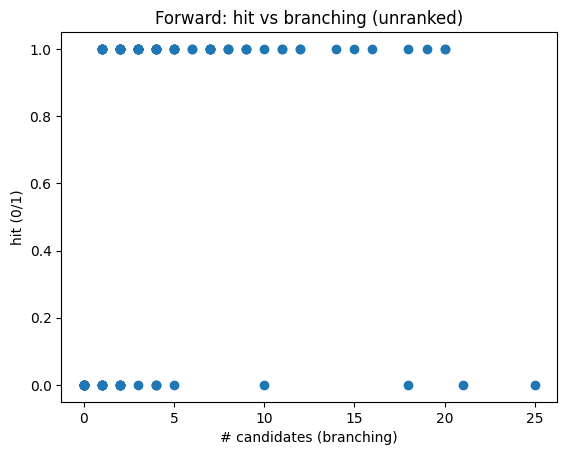

In [8]:
# --- Load data ---
data = load_json_auto("./data/smart.json.gz")
records = to_records(data)
mapped_key = guess_mapped_field(records)
df = pd.DataFrame(records).copy()
df["mapped_rxn"] = df[mapped_key].astype(str)

print("Total reactions:", len(df))
print("Mapped key:", mapped_key)

# --- Build rule library on a prefix (train-like) ---
rules_df = build_rule_library(df, n_rxns=500, core_radius=1, canonicalize=True)
print("Unique rules extracted:", len(rules_df))
display(rules_df[["core_radius", "nL", "nR"]].describe())

# --- Evaluate on a disjoint slice (eval-like) ---
df_eval = df.iloc[500:600].copy()

res_fwd = evaluate_one_step(
    df_eval, rules_df, direction="forward", max_rules=None, max_matches_per_rule=20
)
res_bwd = evaluate_one_step(
    df_eval, rules_df, direction="backward", max_rules=None, max_matches_per_rule=20
)


def summarize(res: pd.DataFrame, name: str):
    print(f"\n=== {name} ===")
    print("Evaluated:", len(res), "hosts")
    print("Runtime (s):", res.attrs.get("runtime_sec"))
    if len(res):
        print("Coverage (n_candidates>0):", (res["n_candidates"] > 0).mean())
        print("Hit rate (unranked recall):", res["hit"].mean())
        print("Avg branching (#candidates):", res["n_candidates"].mean())
        print("Avg rules tried:", res["n_rules_tried"].mean())
        print("Avg rules applicable:", res["n_rules_applicable"].mean())


summarize(res_fwd, "Forward (reactants -> products)")
summarize(res_bwd, "Backward (products -> reactants)")

# --- Simple visualization: hit vs branching ---
if len(res_fwd):
    plt.figure()
    plt.scatter(res_fwd["n_candidates"], res_fwd["hit"].astype(int))
    plt.xlabel("# candidates (branching)")
    plt.ylabel("hit (0/1)")
    plt.title("Forward: hit vs branching (unranked)")
    plt.show()

## 4. Interpretation: what to look for

Typical patterns you will see:

- High **coverage** but low **hit rate** often means rules apply broadly but generate many wrong candidates
  (high branching).
- High **hit rate** with very high branching indicates the truth is present but drowned in many alternatives—
  you need **ranking** (future notebook) or more context (S08).
- Low coverage can mean rules are too specific (context too large, or node/edge matching too strict).

Also note:
- “Hit rate” here is unranked set membership (a generous metric).
- Branching is sensitive to symmetry and deduplication strategy.

In S08 we will vary context radius systematically and plot the trade-off curve.


## 5. Exercises

1. **Indexing.** Improve prefiltering:
   add an edge-count multiset or a degree multiset to the necessary-condition test.
2. **Rule size vs branching.** Plot `nL` (rule size) vs average branching contributed by that rule.
3. **Sanity check.** Reduce `max_matches_per_rule` to 1 and see how branching and hit rate change.
